# Lab 2 Arduino DAQ
Jemila Momoh & Caroline Mahoney

In [ ]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd

from scipy.signal import welch 

%matplotlib widget 


import mplcursors 

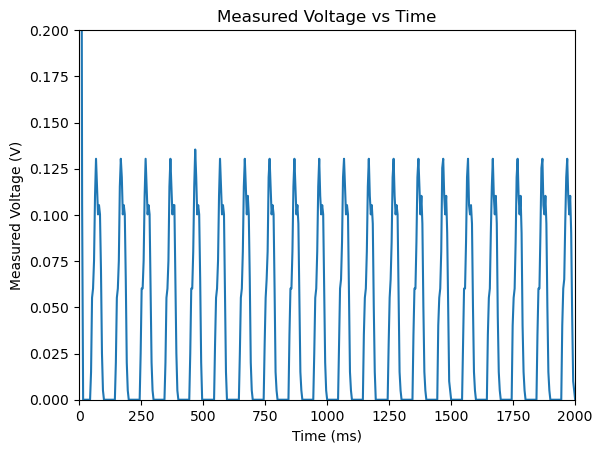

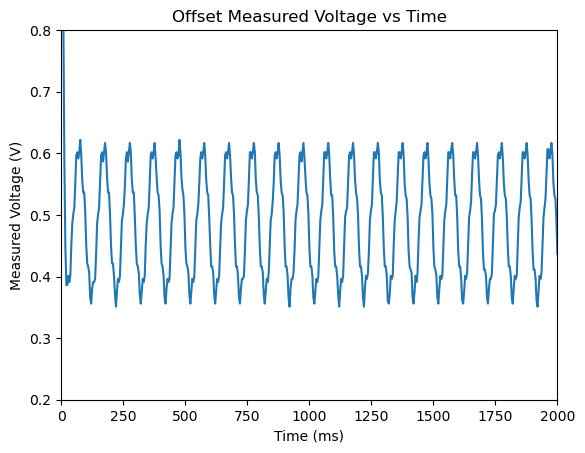

In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd

from scipy.signal import welch # We'll need this for power spectral density estimation 

# For interactive data point selection in plots, this library is useful.
import mplcursors 

data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/lab2data.csv")
data.head()

data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 2000)  # Set x-axis limits
plt.ylim(0, 0.2) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/offset_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Offset Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 2000)  # Set x-axis limits
plt.ylim(0.2, 0.8) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/aliased_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Aliased Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 2000)  # Set x-axis limits
plt.ylim(0.2, 0.8) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/bit_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Bit Noise Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(250, 500)  # Set x-axis limits
plt.ylim(2.45, 2.5) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

# Calculate sampling frequency from time interval
time_interval_ms = data['Time (ms)'].iloc[1] - data['Time (ms)'].iloc[0]  # Time difference between samples in ms
fs_data = 1000 / time_interval_ms  # Convert to Hz (1000 to convert from ms to s)

# Define input parameters for Welch's method
signal_segment_size = 1024
signal_overlap_pct = 60
signal_overlap_size = int(signal_segment_size * signal_overlap_pct / 100)
print(signal_overlap_size)

# Compute Power Spectral Density using Welch's method
f_signal, pxx_signal = welch(data['Sensor 2 (raw)'], fs=fs_data, window="hann", nperseg=signal_segment_size, noverlap=signal_overlap_size)

sns.lineplot(x=f_signal, y=pxx_signal, label='Measured Voltage')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 20000])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Measured Voltage Power Spectral Density')
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()

In [ ]:
data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/aliased_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Aliased Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 2000)  # Set x-axis limits
plt.ylim(0.2, 0.8) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()



In [ ]:
data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/bit_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Bit Noise Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(250, 500)  # Set x-axis limits
plt.ylim(2.45, 2.5) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()



In [ ]:
data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

# Calculate sampling frequency from time interval
time_interval_ms = data['Time (ms)'].iloc[1] - data['Time (ms)'].iloc[0]  # Time difference between samples in ms
fs_data = 1000 / time_interval_ms  # Convert to Hz (1000 to convert from ms to s)

# Define input parameters for Welch's method
signal_segment_size = 1024
signal_overlap_pct = 60
signal_overlap_size = int(signal_segment_size * signal_overlap_pct / 100)
print(signal_overlap_size)

# Compute Power Spectral Density using Welch's method
f_signal, pxx_signal = welch(data['Sensor 2 (raw)'], fs=fs_data, window="hann", nperseg=signal_segment_size, noverlap=signal_overlap_size)

sns.lineplot(x=f_signal, y=pxx_signal, label='Measured Voltage')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 20000])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Measured Voltage Power Spectral Density')
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()

In [ ]:
# impport libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd
from scipy.signal import welch  # Ensure this is included

# For interactive data point selection in plots, this library is useful.
import mplcursors 

data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/offset_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Offset Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 2000)  # Set x-axis limits
plt.ylim(0.2, 0.8) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

,Time (ms),Sensor 0 (raw),Sensor 1 (raw),Sensor 2 (raw)
0,4,507,554,170
1,8,178,299,75
2,12,46,139,21
3,16,1,56,0
4,20,0,17,0


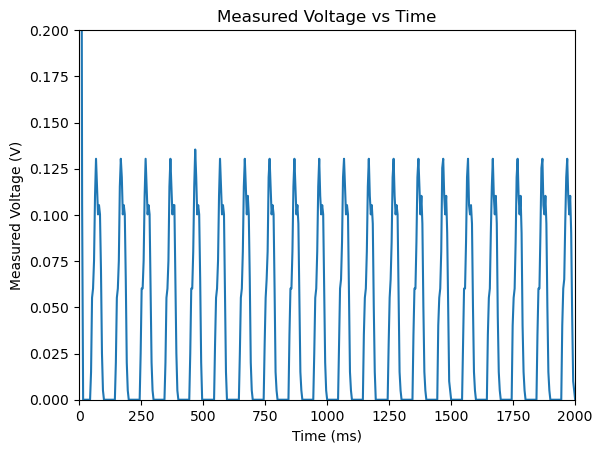

In [ ]:
# impport libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd
from scipy.signal import welch  # Ensure this is included

# For interactive data point selection in plots, this library is useful.
import mplcursors 


data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/aliased_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Aliased Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 2000)  # Set x-axis limits
plt.ylim(0.2, 0.8) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

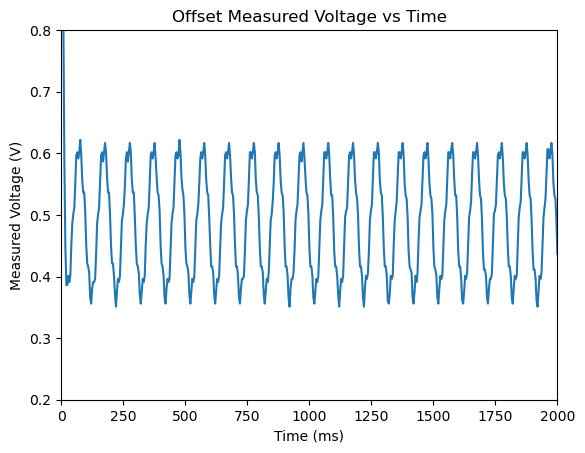

In [ ]:
# impport libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd
from scipy.signal import welch  # Ensure this is included

# For interactive data point selection in plots, this library is useful.
import mplcursors 


data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/bit_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Bit Noise Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(250, 500)  # Set x-axis limits
plt.ylim(2.45, 2.5) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

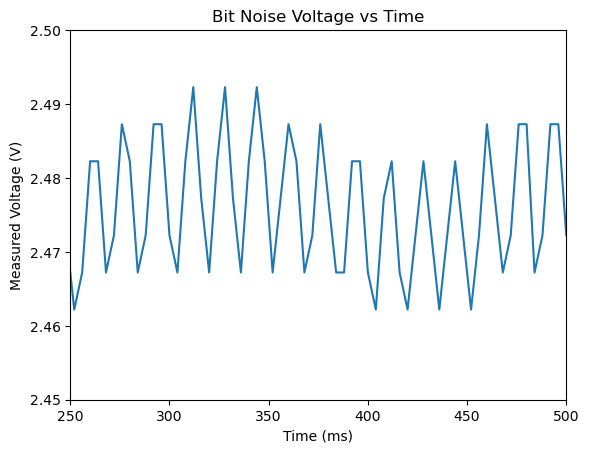

In [ ]:
# impport libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd
from scipy.signal import welch  # Ensure this is included

# For interactive data point selection in plots, this library is useful.
import mplcursors 


data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

# Calculate sampling frequency from time interval
time_interval_ms = data['Time (ms)'].iloc[1] - data['Time (ms)'].iloc[0]  # Time difference between samples in ms
fs_data = 1000 / time_interval_ms  # Convert to Hz (1000 to convert from ms to s)

# Define input parameters for Welch's method
signal_segment_size = 1024
signal_overlap_pct = 60
signal_overlap_size = int(signal_segment_size * signal_overlap_pct / 100)
print(signal_overlap_size)

# Compute Power Spectral Density using Welch's method
f_signal, pxx_signal = welch(data['Sensor 2 (raw)'], fs=fs_data, window="hann", nperseg=signal_segment_size, noverlap=signal_overlap_size)

sns.lineplot(x=f_signal, y=pxx_signal, label='Measured Voltage')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 20000])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Measured Voltage Power Spectral Density')
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 512 is greater than input length  = 500, using nperseg = 500
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/var/folders/21/w0c249pj6ys3hd6srsl1sfx00000gn/T/ipykernel_41738/3070046527.py:35: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 200)  # Set x-axis limits


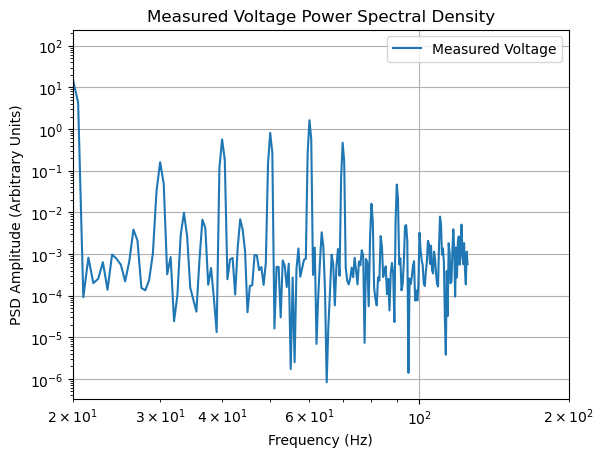

In [3]:
# impport libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd
from scipy.signal import welch  # Ensure this is included

# For interactive data point selection in plots, this library is useful.
import mplcursors 


data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

# Calculate sampling frequency from time interval
time_interval_ms = data['Time (ms)'].iloc[1] - data['Time (ms)'].iloc[0]
fs_data = 1000 / time_interval_ms  # Convert ms to seconds, then take reciprocal

# Define input parameters for Welch's method
signal_segment_size = 512
signal_overlap_pct = 60
signal_overlap_size = int(signal_segment_size * signal_overlap_pct / 100)

# Compute Power Spectral Density using Welch's method
f_signal, pxx_signal = welch(data['Sensor 2 (raw)'], fs=fs_data, window="hann", nperseg=signal_segment_size, noverlap=signal_overlap_size)

sns.lineplot(x=f_signal, y=pxx_signal, label='Measured Voltage')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 20000])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Measured Voltage Power Spectral Density')
plt.xlim(0, 200)  # Set x-axis limits
#plt.ylim(2.45, 2.5) # Set y-axis limits
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 512 is greater than input length  = 500, using nperseg = 500
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/var/folders/21/w0c249pj6ys3hd6srsl1sfx00000gn/T/ipykernel_41738/1197923932.py:35: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 200)  # Set x-axis limits


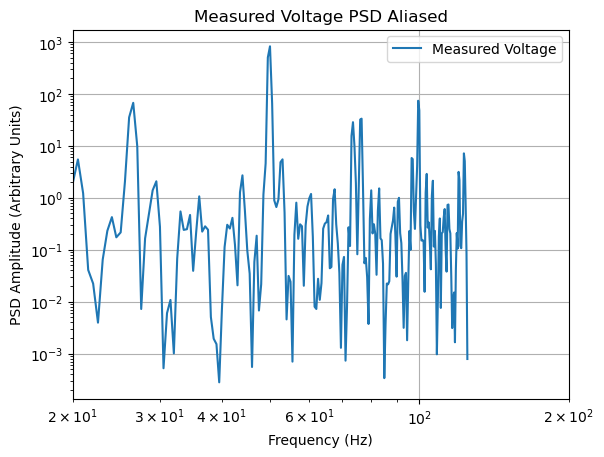

In [4]:
# impport libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd
from scipy.signal import welch  # Ensure this is included

# For interactive data point selection in plots, this library is useful.
import mplcursors 


data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/aliased_lab2data.csv")
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

# Calculate sampling frequency from time interval
time_interval_ms = data['Time (ms)'].iloc[1] - data['Time (ms)'].iloc[0]
fs_data = 1000 / time_interval_ms  # Convert ms to seconds, then take reciprocal

# Define input parameters for Welch's method
signal_segment_size = 512
signal_overlap_pct = 60
signal_overlap_size = int(signal_segment_size * signal_overlap_pct / 100)

# Compute Power Spectral Density using Welch's method
f_signal, pxx_signal = welch(data['Sensor 2 (raw)'], fs=fs_data, window="hann", nperseg=signal_segment_size, noverlap=signal_overlap_size)

sns.lineplot(x=f_signal, y=pxx_signal, label='Measured Voltage')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 20000])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Measured Voltage PSD Aliased')
plt.xlim(0, 200)  # Set x-axis limits
#plt.ylim(2.45, 2.5) # Set y-axis limits
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()